['Luhandjula', 'Mizumoto1', 'Mizumoto2', 'R5p', 'Sales1', 'Sales2', 'Werners1', 'Werners2', 'Zimmermann1', 'Zimmermann2']
[np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2)]
[np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95), np.float64(1.0)]


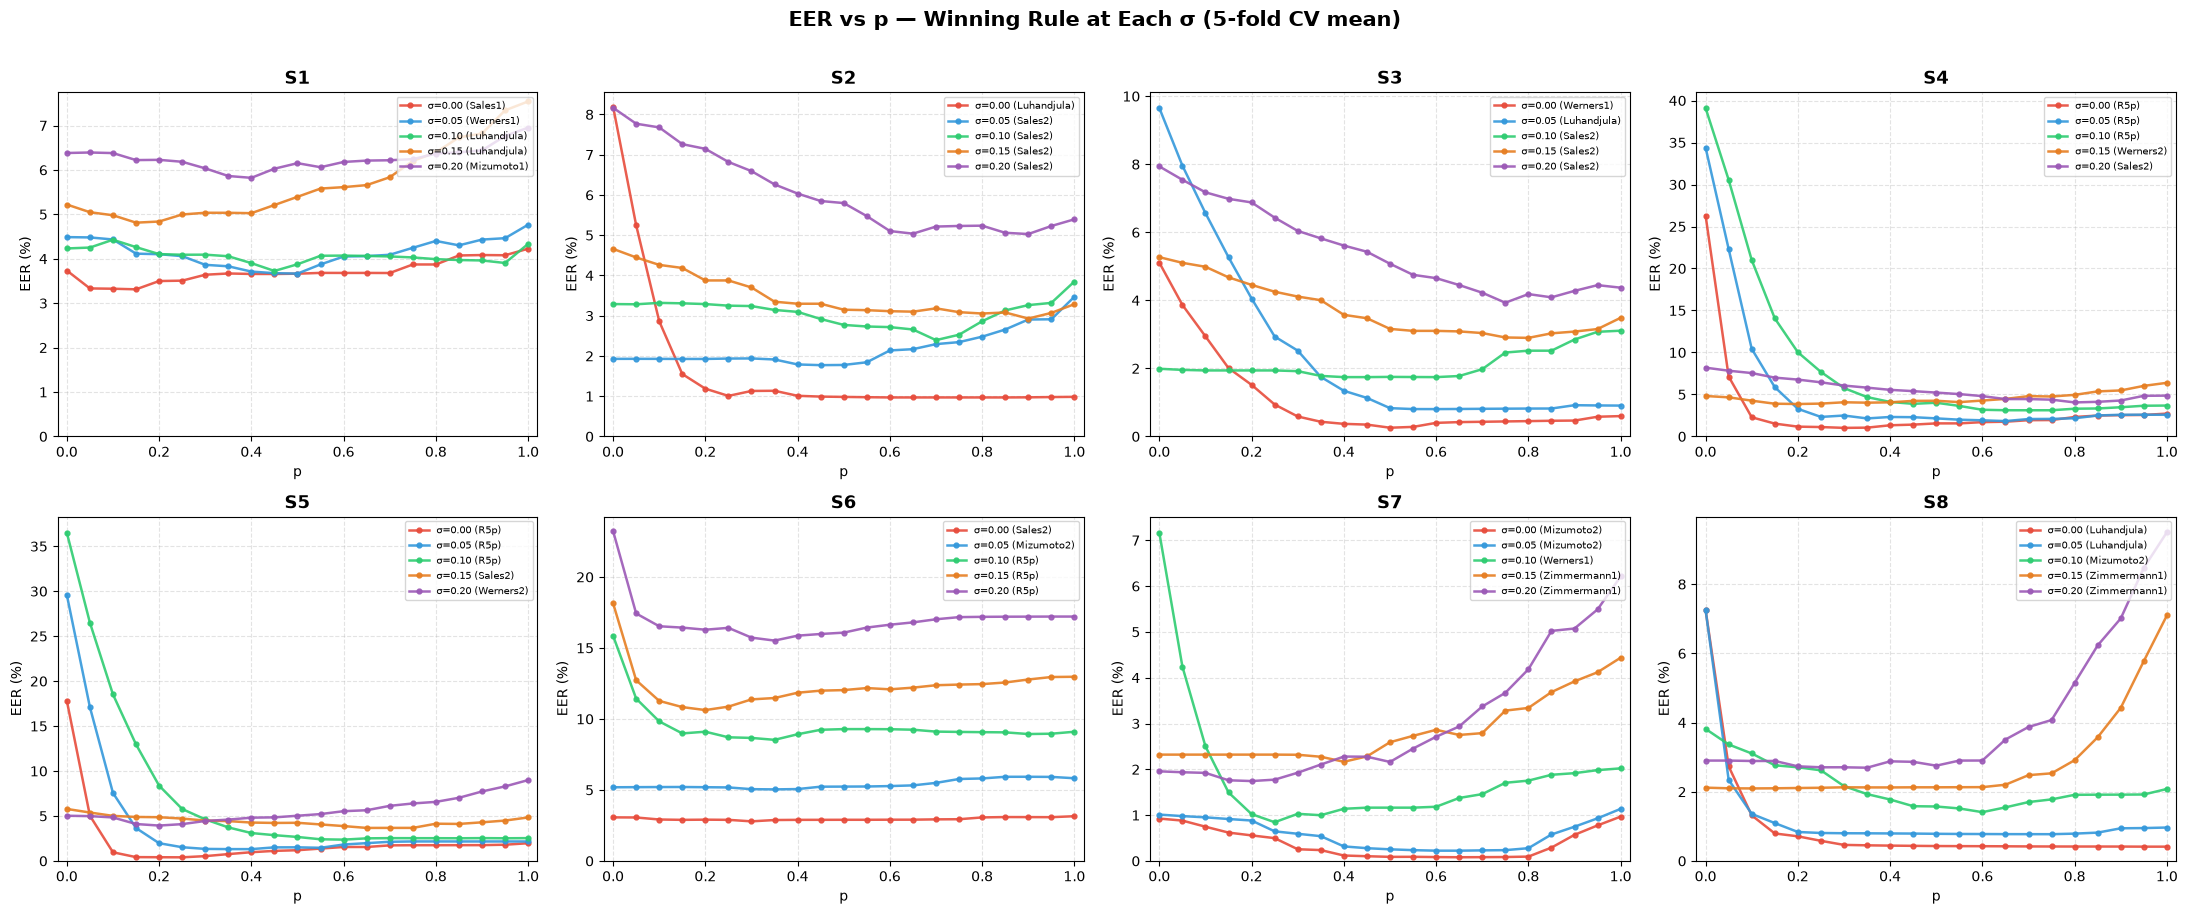

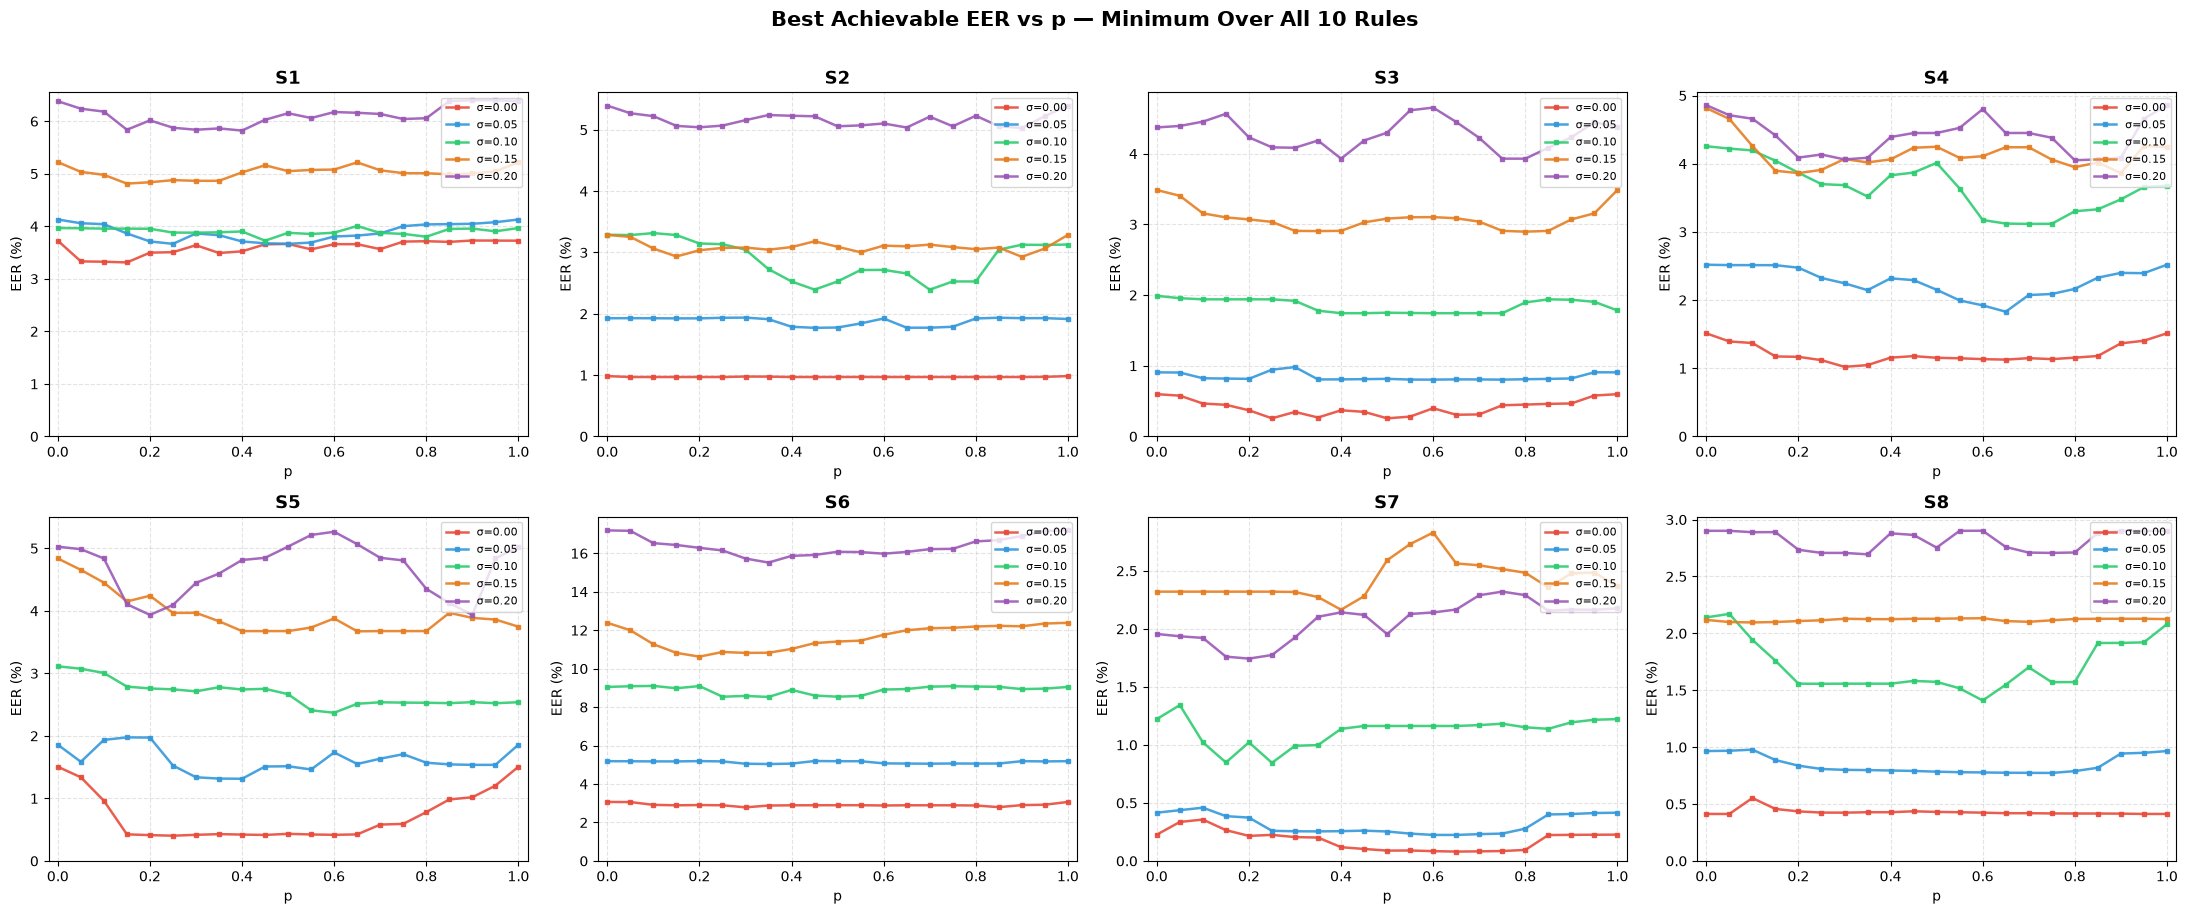

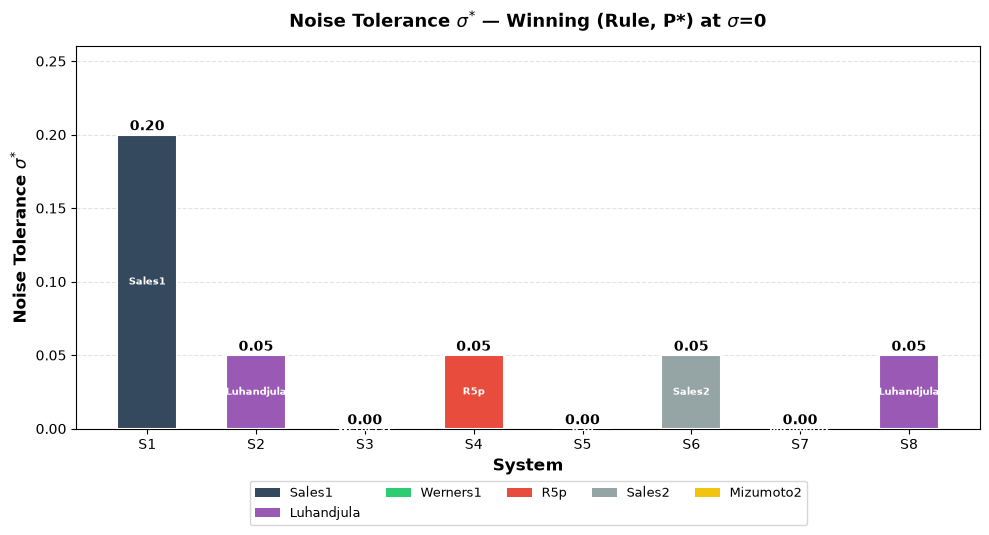

[[ 2.13797244  2.13793582  3.22551948  2.58537246  2.73022036  5.03819012
   2.27716392  5.23110186  3.22654456  2.27243774]
 [ 7.19790152 18.19094214  7.19790152  5.62949374 21.4476677   4.04525248
   7.19790152  4.05758978  5.62949374  4.0725263 ]
 [ 7.66864634 19.57926972  7.62944732  5.57726762 22.42827594  3.33209758
   7.67987638  3.33209758  5.41036738  3.67374644]
 [ 7.06426    17.99286854  7.01758338  4.07300224 12.74068664  2.53884226
   7.05679174  2.55072192  3.63508398  2.9149094 ]
 [ 8.5778273  19.939778    8.33666474  5.18236832 15.13437378  2.6184305
   8.57592364  2.4285573   4.62903982  3.51766024]
 [12.93638066 14.41873874 13.78166688 12.563407   11.56990876 14.40241106
  13.00507768 14.39280118 14.1310277  13.09491646]
 [ 2.35360696  0.98775056  2.08369656  3.21731756 -0.75330186  4.24840762
   2.33725528  7.39086212  1.47672746  2.50808704]
 [ 3.03463952  0.95524166  2.47329364  4.38635796 -1.66895474  5.58872952
   3.07247506  8.15424154  2.02276352  3.0677525 ]]


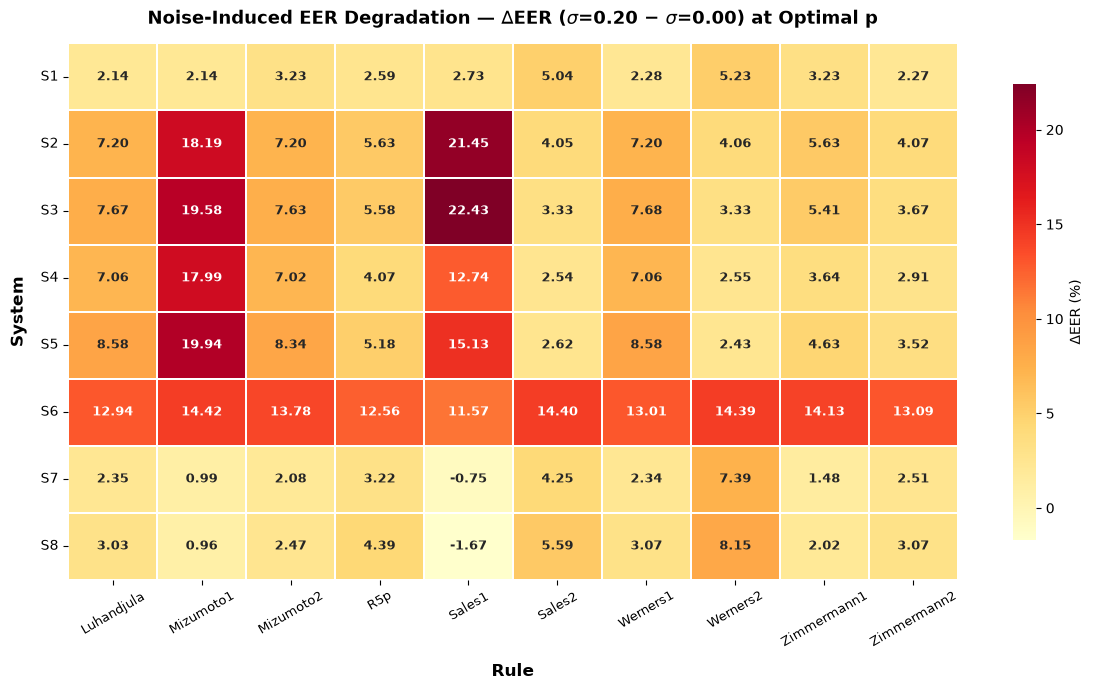

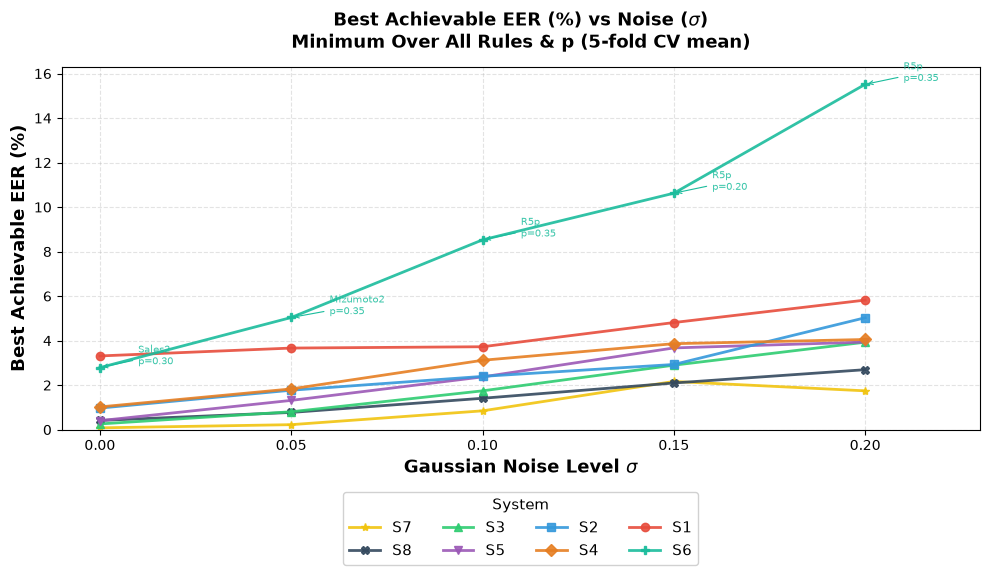


GRID: Best Achievable EER (%) per Rule vs Sigma — min over all systems & p
Rule              σ=0.00    σ=0.05    σ=0.10    σ=0.15    σ=0.20
----------------------------------------------------------------
Zimmermann1       0.2672    0.4109    1.1946    2.0961    1.7439
Mizumoto2         0.0807    0.2242    1.1388    2.1256    2.1644
Luhandjula        0.2016    0.2548    0.8487    2.5088    2.5552
Werners1          0.2159    0.3719    0.8455    2.4049    2.5532
Zimmermann2       0.2159    0.3738    1.0220    2.4049    2.7240
Mizumoto1         0.9675    1.1370    1.3474    2.1018    1.9553
R5p               0.2435    0.4279    0.9998    3.0785    3.4608
Sales2            0.2267    0.4157    1.2225    2.8973    3.9302
Werners2          0.5981    0.9070    1.7439    2.9057    3.9302
Sales1            3.3120    3.8933    3.8762    4.9890    5.5853

--------------------------------------------------------------------------------
Winning System at Each (Rule, Sigma)
-------------------------

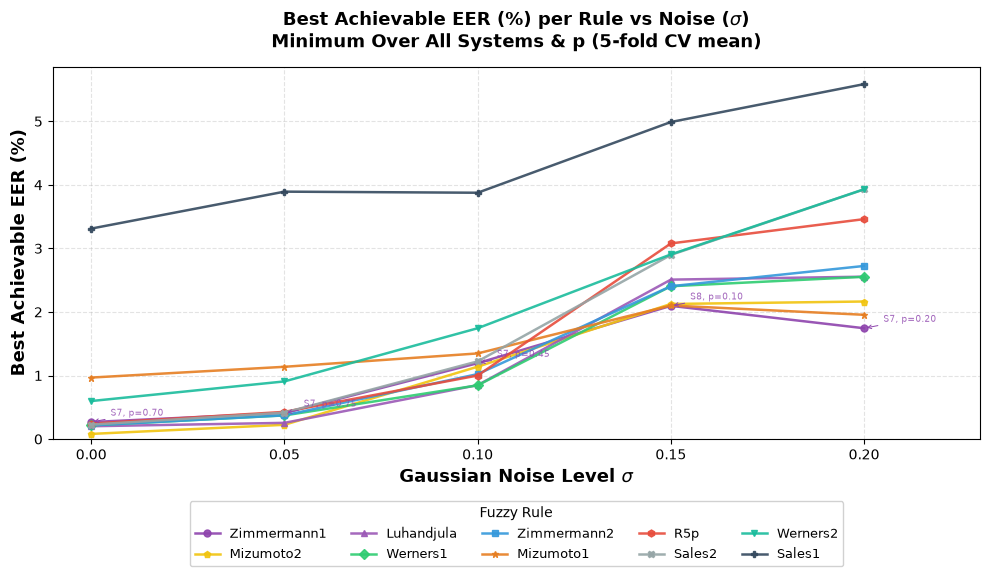

[DONE] All available plots generated.


In [3]:
#!/usr/bin/env python3
"""
Generate 4 plots from the full EER grid (Fold, System, Sigma, Rule, p, EER, Rank1).
Save the document content as 'FullEERGrid.txt', then run:
    python plot_noise_robustness.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_FILE = "C:/Users/Fdl/OneDrive/Desktop/tmpppppppp/rawnoisedata.txt"

# ── Read & prepare ─────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_FILE, sep="\t")
df.columns = df.columns.str.strip()
df["EER"]    = pd.to_numeric(df["EER"],    errors="coerce") * 100
df["Rank1"]  = pd.to_numeric(df["Rank1"],  errors="coerce") * 100
df.rename(columns={"p": "P", "Rank1": "R1"}, inplace=True)

systems = ["S1","S2","S3","S4","S5","S6","S7","S8"]
rules   = sorted(df["Rule"].unique())
print(rules)
sigmas  = sorted(df["Sigma"].unique())
print(sigmas)
p_vals  = sorted(df["P"].unique())
print(p_vals)
# Mean over folds per (System, Sigma, Rule, P)
agg = (df.groupby(["System","Sigma","Rule","P"])
         .agg(EER=("EER","mean"), R1=("R1","mean"))
         .reset_index())

# ── Find winning rule per (System, Sigma) ─────────────────────────────────
winning = {}
for sys in systems:
    for sig in sigmas:
        sub = agg[(agg["System"]==sys) & (agg["Sigma"]==sig)]
        if len(sub) == 0:
            continue
        best = sub.loc[sub["EER"].idxmin()]
        winning[(sys, sig)] = {
            "rule": best["Rule"], "p": best["P"], "eer": best["EER"]
        }

# ═══════════════════════════════════════════════════════════════════════════
#  FIG 1 — EER vs p  (winning rule per system, curves per sigma)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.patch.set_facecolor("white")

colors_sigma = {0: "#E74C3C", 0.05: "#3498DB", 0.10: "#2ECC71",
                0.15: "#E67E22", 0.20: "#9B59B6"}

for idx, sys in enumerate(systems):
    ax = axes[idx // 4, idx % 4]
    for sig in sigmas:
        key = (sys, sig)
        if key not in winning:
            continue
        wrule = winning[key]["rule"]
        curve = agg[(agg["System"]==sys) & (agg["Sigma"]==sig) & (agg["Rule"]==wrule)]
        if len(curve) == 0:
            continue
        c = colors_sigma.get(sig, "#34495E")
        ax.plot(curve["P"], curve["EER"], marker="o", markersize=3.5,
                linewidth=1.8, color=c, alpha=0.9,
                label=f"σ={sig:.2f} ({wrule})")

    ax.set_title(sys, fontsize=13, fontweight="bold")
    ax.set_xlabel("p", fontsize=10)
    ax.set_ylabel("EER (%)", fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=7, loc="upper right", framealpha=0.8)

fig.suptitle("EER vs p — Winning Rule at Each σ (5-fold CV mean)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./Results/Fig1_EER_vs_P_WinningRule.png", dpi=200, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
#  FIG 2 — Best achievable EER vs p (envelope over all 10 rules)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.patch.set_facecolor("white")

for idx, sys in enumerate(systems):
    ax = axes[idx // 4, idx % 4]
    for sig in sigmas:
        sub = agg[(agg["System"]==sys) & (agg["Sigma"]==sig)]
        if len(sub) == 0:
            continue
        envelope = sub.groupby("P")["EER"].min()
        c = colors_sigma.get(sig, "#34495E")
        ax.plot(envelope.index, envelope.values,
                marker="s", markersize=3, linewidth=1.8,
                color=c, alpha=0.9, label=f"σ={sig:.2f}")

    ax.set_title(sys, fontsize=13, fontweight="bold")
    ax.set_xlabel("p", fontsize=10)
    ax.set_ylabel("EER (%)", fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=8, loc="upper right", framealpha=0.8)

fig.suptitle("Best Achievable EER vs p — Minimum Over All 10 Rules",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./Results/Fig2_Best_EER_vs_P_Envelope.png", dpi=200, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
#  FIG 3 — Sigma* bar chart (noise tolerance per system)
# ═══════════════════════════════════════════════════════════════════════════
if len(sigmas) >= 2:
    sigma_stars = {}
    for sys in systems:
        if (sys, sigmas[0]) not in winning:
            continue
        base_eer = winning[(sys, sigmas[0])]["eer"]
        if base_eer < 0.01:
            base_eer = 0.01  # avoid zero threshold for near-perfect systems
        threshold = 2.0 * base_eer
        sigma_star = 0.0
        for sig in sigmas:
            key = (sys, sig)
            if key in winning and winning[key]["eer"] <= threshold:
                sigma_star = sig
            else:
                break
        sigma_stars[sys] = sigma_star

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor("white")

    sys_order = list(sigma_stars.keys())
    values    = list(sigma_stars.values())
    rule_at_0 = [winning[(s, sigmas[0])]["rule"] if (s, sigmas[0]) in winning else ""
                 for s in sys_order]

    rule_colors = {
        "R5p": "#E74C3C", "Zimmermann2": "#3498DB", "Luhandjula": "#9B59B6",
        "Werners1": "#2ECC71", "Werners2": "#1ABC9C", "Mizumoto2": "#F1C40F",
        "Mizumoto1": "#E67E22", "Sales1": "#34495E", "Sales2": "#95A5A6",
        "Zimmermann1": "#8E44AD",
    }
    bar_colors = [rule_colors.get(r, "#95A5A6") for r in rule_at_0]

    bars = ax.bar(sys_order, values, width=0.55,
                  color=bar_colors, edgecolor="white", linewidth=1.5, zorder=3)

    for bar, v, r in zip(bars, values, rule_at_0):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")
        ax.text(bar.get_x() + bar.get_width()/2, v/2,
                r, ha="center", va="center",
                fontsize=7, color="white", fontweight="bold", rotation=0)

    ax.set_xlabel("System", fontsize=12, fontweight="bold")
    ax.set_ylabel(r"Noise Tolerance $\sigma^{*}$", fontsize=12, fontweight="bold")
    ax.set_title(
        r"Noise Tolerance $\sigma^{*}$ — Winning (Rule, P*) at $\sigma$=0",
        fontsize=13, fontweight="bold", pad=14)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.set_ylim(0, max(values) * 1.3 if values else 1)

    unique_rules = list(dict.fromkeys(rule_at_0))
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=rule_colors.get(r, "#95A5A6"), label=r)
                       for r in unique_rules]
    ax.legend(handles=legend_elements,
              loc="upper center", bbox_to_anchor=(0.5, -0.12),
              ncol=min(len(unique_rules), 5), fontsize=9)

    plt.tight_layout()
    plt.savefig("./Results/Fig3_Sigma_Star_Bar.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("[INFO] Only one sigma level found — skipping Fig 3 (Sigma* bar chart).")

# ═══════════════════════════════════════════════════════════════════════════
#  FIG 4 — ΔEER heatmap (System × Rule, degradation from σ_min to σ_max)
# ═══════════════════════════════════════════════════════════════════════════
if len(sigmas) >= 2:
    sig_lo, sig_hi = sigmas[0], sigmas[-1]

    delta = np.full((len(systems), len(rules)), np.nan)
    for i, sys in enumerate(systems):
        for j, rule in enumerate(rules):
            e_lo = agg[(agg["System"]==sys) & (agg["Sigma"]==sig_lo) & (agg["Rule"]==rule)]
            e_hi = agg[(agg["System"]==sys) & (agg["Sigma"]==sig_hi) & (agg["Rule"]==rule)]
            if len(e_lo) > 0 and len(e_hi) > 0:
                delta[i, j] = e_hi["EER"].min() - e_lo["EER"].min()

    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor("white")

    print(delta)
    
    sns.heatmap(delta, ax=ax, cmap="YlOrRd",
                xticklabels=rules, yticklabels=systems,
                annot=True, fmt=".2f",
                annot_kws={"size": 9, "fontweight": "bold"},
                linewidths=1.2, linecolor="white",
                cbar_kws={"label": r"$\Delta$EER (%)", "shrink": 0.85})

    ax.set_xlabel("Rule", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_ylabel("System", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_title(
        f"Noise-Induced EER Degradation — "
        f"$\\Delta$EER ($\\sigma$={sig_hi:.2f} $-$ $\\sigma$={sig_lo:.2f}) at Optimal p",
        fontsize=13, fontweight="bold", pad=14)
    ax.tick_params(axis="y", labelsize=10, rotation=0)
    ax.tick_params(axis="x", labelsize=9, rotation=30)

    plt.tight_layout()
    plt.savefig("./Results/Fig4_DeltaEER_Heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("[INFO] Only one sigma level found — skipping Fig 4 (ΔEER heatmap).")

# ═══════════════════════════════════════════════════════════════════════════
#  FIG 5 — Best Achievable EER vs Sigma (envelope over all rules & p)
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")

sys_colors = {
    "S1": "#E74C3C", "S2": "#3498DB", "S3": "#2ECC71", "S4": "#E67E22",
    "S5": "#9B59B6", "S6": "#1ABC9C", "S7": "#F1C40F", "S8": "#34495E",
}
sys_markers = {
    "S1": "o", "S2": "s", "S3": "^", "S4": "D",
    "S5": "v", "S6": "P", "S7": "*", "S8": "X",
}

# For each (System, Sigma): find min EER over all Rule & P
envelope = {}
for sys in systems:
    vals = []
    for sig in sigmas:
        sub = agg[(agg["System"] == sys) & (agg["Sigma"] == sig)]
        if len(sub) > 0:
            vals.append((sig, sub["EER"].min()))
    if vals:
        envelope[sys] = vals

# Plot curves (order by mean EER so legend is sorted)
order = sorted(envelope, key=lambda s: np.mean([v for _, v in envelope[s]]))
for sys in order:
    xs = [v[0] for v in envelope[sys]]
    ys = [v[1] for v in envelope[sys]]
    ax.plot(xs, ys, color=sys_colors.get(sys, "#34495E"),
            marker=sys_markers.get(sys, "o"), markersize=6,
            linewidth=2, label=sys, alpha=0.9)

# Annotate the optimal (rule, p) at each sigma for the overall best system
best_sys = order[-1]  # lowest mean EER
for sig, eer in envelope[best_sys]:
    sub = agg[(agg["System"] == best_sys) & (agg["Sigma"] == sig)]
    r = sub.loc[sub["EER"].idxmin()]
    ax.annotate(f"{r['Rule']}\np={r['P']:.2f}",
                xy=(sig, eer),
                xytext=(sig + 0.01, eer + 0.15),
                fontsize=7, color=sys_colors.get(best_sys, "#34495E"),
                arrowprops=dict(arrowstyle="->", color=sys_colors.get(best_sys, "#34495E"),
                                lw=0.8),
                alpha=0.85)

ax.set_xlabel(r"Gaussian Noise Level $\sigma$", fontsize=13, fontweight="bold")
ax.set_ylabel("Best Achievable EER (%)", fontsize=13, fontweight="bold")
ax.set_title(
    "Best Achievable EER (%) vs Noise ($\\sigma$)\n"
    "Minimum Over All Rules & p (5-fold CV mean)",
    fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(-0.01, max(sigmas) + 0.03)
ax.set_ylim(bottom=0)
ax.set_xticks(sigmas)
ax.set_xticklabels([f"{s:.2f}" for s in sigmas], fontsize=10)
ax.grid(True, linestyle="--", alpha=0.35)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15),
          ncol=4, fontsize=11, framealpha=0.9,
          title="System", title_fontsize=11)

plt.tight_layout()
plt.savefig("Fig5_Best_EER_vs_Sigma.png", dpi=200, bbox_inches="tight")
plt.savefig("Fig5_Best_EER_vs_Sigma.pdf", bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
#  FIG 6 — Best EER per Rule vs Sigma (min over all systems & p, 5-fold CV)
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")

rule_colors = {
    "Zimmermann1": "#8E44AD", "Zimmermann2": "#3498DB",
    "Luhandjula":  "#9B59B6", "Werners1":    "#2ECC71",
    "Werners2":    "#1ABC9C", "Sales1":      "#34495E",
    "Sales2":      "#95A5A6", "Mizumoto1":   "#E67E22",
    "Mizumoto2":   "#F1C40F", "R5p":        "#E74C3C",
}
rule_markers = {
    "Zimmermann1": "o",  "Zimmermann2": "s",
    "Luhandjula":  "^",  "Werners1":    "D",
    "Werners2":    "v",  "Sales1":      "P",
    "Sales2":      "X",  "Mizumoto1":   "*",
    "Mizumoto2":   "p",  "R5p":         "h",
}

# For each (Rule, Sigma): find min EER over all systems & p
rule_envelope = {}
for rule in rules:
    vals = []
    for sig in sigmas:
        sub = agg[(agg["Rule"] == rule) & (agg["Sigma"] == sig)]
        if len(sub) > 0:
            best_row = sub.loc[sub["EER"].idxmin()]
            vals.append({
                "sigma": sig,
                "eer":   best_row["EER"],
                "sys":   best_row["System"],
                "p":     best_row["P"],
            })
    if vals:
        rule_envelope[rule] = vals

# Plot curves (order by mean EER so legend is sorted: best at top)
rule_order = sorted(rule_envelope, key=lambda r: np.mean([v["eer"] for v in rule_envelope[r]]))

# ── Print Grid: Best EER per Rule vs Sigma ────────────────────────────────
print("\n" + "=" * 80)
print("GRID: Best Achievable EER (%) per Rule vs Sigma — min over all systems & p")
print("=" * 80)

# ── EER grid ──────────────────────────────────────────────────────────────
header = f"{'Rule':<14}" + "".join([f"σ={s:.2f}" .rjust(10) for s in sigmas])
print(header)
print("-" * (14 + 10 * len(sigmas)))

for rule in rule_order:
    row = f"{rule:<14}"
    for sig in sigmas:
        match = [v for v in rule_envelope[rule] if v["sigma"] == sig]
        if match:
            row += f"{match[0]['eer']:.4f}".rjust(10)
        else:
            row += f"{'—':>10}"
    print(row)

# ── Winning System grid ───────────────────────────────────────────────────
print("\n" + "-" * 80)
print("Winning System at Each (Rule, Sigma)")
print("-" * 80)

header2 = f"{'Rule':<14}" + "".join([f"σ={s:.2f}".rjust(10) for s in sigmas])
print(header2)
print("-" * (14 + 10 * len(sigmas)))

for rule in rule_order:
    row = f"{rule:<14}"
    for sig in sigmas:
        match = [v for v in rule_envelope[rule] if v["sigma"] == sig]
        if match:
            row += f"{match[0]['sys']}".rjust(10)
        else:
            row += f"{'—':>10}"
    print(row)

# ── Winning P grid ────────────────────────────────────────────────────────
print("\n" + "-" * 80)
print("Optimal p at Each (Rule, Sigma)")
print("-" * 80)

header3 = f"{'Rule':<14}" + "".join([f"σ={s:.2f}".rjust(10) for s in sigmas])
print(header3)
print("-" * (14 + 10 * len(sigmas)))

for rule in rule_order:
    row = f"{rule:<14}"
    for sig in sigmas:
        match = [v for v in rule_envelope[rule] if v["sigma"] == sig]
        if match:
            row += f"{match[0]['p']:.2f}".rjust(10)
        else:
            row += f"{'—':>10}"
    print(row)

print("=" * 80)

for rule in rule_order:
    xs = [v["sigma"] for v in rule_envelope[rule]]
    ys = [v["eer"]   for v in rule_envelope[rule]]
    ax.plot(xs, ys, color=rule_colors.get(rule, "#95A5A6"),
            marker=rule_markers.get(rule, "o"), markersize=5,
            linewidth=1.8, label=rule, alpha=0.9)

# Annotate the optimal system/p at each sigma for the best rule
best_rule = rule_order[0]
for entry in rule_envelope[best_rule]:
    ax.annotate(f"{entry['sys']}, p={entry['p']:.2f}",
                xy=(entry["sigma"], entry["eer"]),
                xytext=(entry["sigma"] + 0.005, entry["eer"] + 0.1),
                fontsize=6.5, color=rule_colors.get(best_rule, "#E74C3C"),
                arrowprops=dict(arrowstyle="->",
                                color=rule_colors.get(best_rule, "#E74C3C"),
                                lw=0.7),
                alpha=0.8)

ax.set_xlabel(r"Gaussian Noise Level $\sigma$", fontsize=13, fontweight="bold")
ax.set_ylabel("Best Achievable EER (%)", fontsize=13, fontweight="bold")
ax.set_title(
    "Best Achievable EER (%) per Rule vs Noise ($\\sigma$)\n"
    "Minimum Over All Systems & p (5-fold CV mean)",
    fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(-0.01, max(sigmas) + 0.03)
ax.set_ylim(bottom=0)
ax.set_xticks(sigmas)
ax.set_xticklabels([f"{s:.2f}" for s in sigmas], fontsize=10)
ax.grid(True, linestyle="--", alpha=0.35)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15),
          ncol=5, fontsize=9, framealpha=0.9,
          title="Fuzzy Rule", title_fontsize=10)

plt.tight_layout()
plt.savefig("./Results/Fig6_Best_EER_per_Rule_vs_Sigma.png", dpi=200, bbox_inches="tight")
plt.show()

print("[DONE] All available plots generated.")